In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [5]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, tolerance=0.0001, max_iter=1000):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iter = max_iter

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.bias, self.weights = 0, np.zeros(n_features)
        previous_db, previous_dw = 0, np.zeros(n_features)

        for _ in range(self.max_iter):
            y_pred_linear = X @ self.weights + self.bias
            y_pred_sigmoid = 1 / (1 + np.exp(-y_pred_linear))
            db = 1 / n_samples * np.sum(y_pred_sigmoid - y)
            dw = 1 / n_samples * X.T @ (y_pred_sigmoid - y)

            self.bias -= self.learning_rate * db
            self.weights -= self.learning_rate * dw
            abs_db_reduction = np.abs(db - previous_db)
            abs_dw_reduction = np.abs(dw - previous_dw)

            if abs_db_reduction < self.tolerance:
                if abs_dw_reduction.all() < self.tolerance:
                    break

            previous_db = db
            previous_dw = dw

    def predict(self, X_test):
        y_pred_linear = X_test @ self.weights + self.bias
        y_pred_sigmoid = 1 / (1 + np.exp(-y_pred_linear))
        classes = np.array([0 if pred < 0.5 else 1 for pred in y_pred_sigmoid])

        return classes

In [6]:
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train.values[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train.values)

    def plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf):
        plt.xlabel(feature1_name)
        plt.ylabel(feature2_name)
        plt.title(title)

In [7]:
class StandardScaler:
    def fit_transform(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        return (X - self.mean) / self.std

In [8]:
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train.values[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train.values)

    plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf)
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title(title)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [10]:
df = pd.read_csv("heart.csv")
print(df.sample(7))

X, y = df.iloc[:, :-1], df.iloc[:, -1]
X_scaled = StandardScaler().fit_transform(X)
y = pd.Series(LabelEncoder().fit_transform(y))

     age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
88    54    0   2     110   214    0        1       158     0      1.6    1   
233   64    1   0     120   246    0        0        96     1      2.2    0   
79    58    1   2     105   240    0        0       154     1      0.6    1   
58    34    1   3     118   182    0        0       174     0      0.0    2   
181   65    0   0     150   225    0        0       114     0      1.0    1   
245   48    1   0     124   274    0        0       166     0      0.5    1   
199   65    1   0     110   248    0        0       158     0      0.6    2   

     caa  thall  output  
88     0      2       1  
233    1      2       0  
79     0      3       1  
58     0      2       1  
181    3      3       0  
245    0      3       0  
199    2      1       0  


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size= 0.2, random_state=42)

In [12]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(f'Logistic regression accuracy: {accuracy}')
print(f'prediction: {y_pred}')

Logistic regression accuracy: 0.8524590163934426
prediction: [0 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]


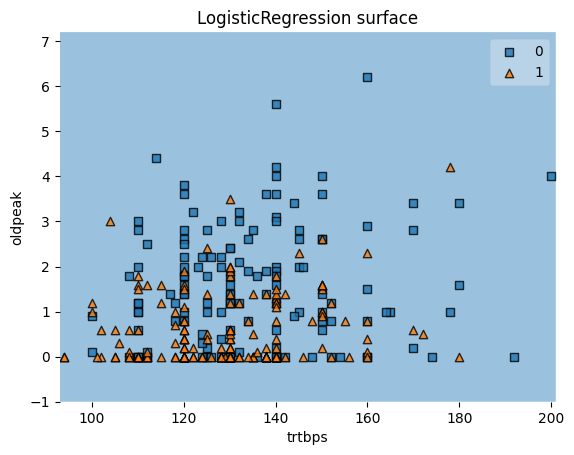

In [13]:
feature_indexes = [3, 9]
title1 = 'LogisticRegression surface'
decision_boundary_plot(X, y, X_train, y_train, lr, feature_indexes, title1)